In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
# from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_noise/int_3mth_new'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.512705  ,  0.495245  ,  0.303085  ,  0.769355  ,  0.552835  ],
        [ 0.5216043 ,  0.48384813,  0.29420075,  0.77775817,  0.55248994],
        [ 0.52432919,  0.49850597,  0.29569639,  0.756709  ,  0.54701965],
        ...,
        [ 0.53902549,  0.2020312 ,  0.39060152,  0.87767148, -0.06864286],
        [ 0.65798972,  0.53262529, -0.32565612,  1.60705634,  0.94595787],
        [-0.13728218, -0.92548738,  0.08457074,  0.16513526, -0.13751737]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([5.47856108, 3.10040594, 2.71956552, ...,       -inf,       -inf,
              -inf])]

In [ ]:
sampler.now_covariances

[array([[ 0.04733625,  0.04034993,  0.00292217, -0.03591503,  0.00689124],
        [ 0.04034993,  0.22356962,  0.01579661,  0.01887789, -0.02094393],
        [ 0.00292217,  0.01579661,  0.23289204, -0.00259045,  0.01640477],
        [-0.03591503,  0.01887789, -0.00259045,  0.26323022, -0.01374274],
        [ 0.00689124, -0.02094393,  0.01640477, -0.01374274,  0.24157748]])]

In [ ]:
np.argmax(logden_list)

968

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.1179571 , 1.18952974, 0.78922904, 9.84163333, 0.35247262]])

In [10]:
log_density(maxld_pt1)

array([5.69902245])

In [11]:
log_density([param_true])

array([9.92879914])

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [ ]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

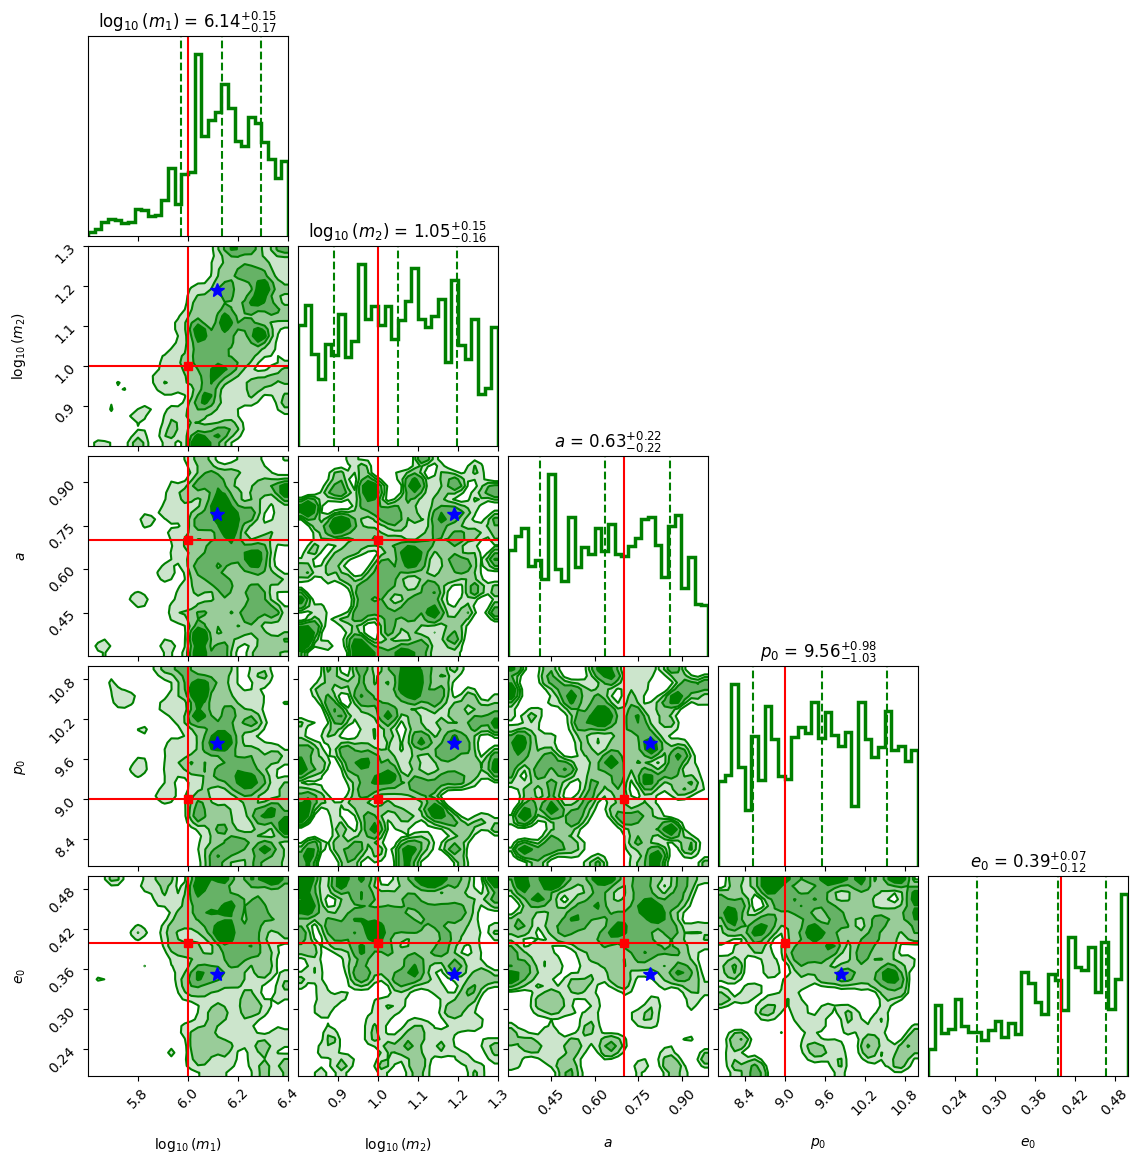

In [15]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [16]:
np.sort(logden_list)

array([[      -inf,       -inf,       -inf, ..., 5.40156039, 5.47856108,
        5.69902245]])

In [17]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([ 968,    0,  761,  700, 1429,  812,  117, 2808,  401,  408])

In [18]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[ 6.1179571 ,  1.18952974,  0.78922904,  9.84163333,  0.35247262],
       [ 6.010164  ,  1.0476225 ,  0.50912865, 10.308065  ,  0.3658505 ],
       [ 6.0442762 ,  1.0254331 ,  0.62711779, 10.21113118,  0.29497227],
       [ 6.02834289,  0.98482847,  0.51038675, 10.55259607,  0.39394456],
       [ 6.14339134,  1.18543361,  0.63845148, 10.35080395,  0.40147813],
       [ 6.0854192 ,  1.03384542,  0.42990843, 10.1065132 ,  0.41976525],
       [ 6.04330609,  1.05611263,  0.53404594, 10.15252563,  0.37027948],
       [ 6.11830222,  0.98563136,  0.86100312,  8.50850005,  0.41907004],
       [ 6.00411621,  1.0256104 ,  0.50160472, 10.52302949,  0.37919856],
       [ 6.01679804,  1.04229806,  0.51139474, 10.02338322,  0.35980328]])

In [3]:
import numpy as np 
top10_pts = np.array([[ 6.1179571 ,  1.18952974,  0.78922904,  9.84163333,  0.35247262],
       [ 6.010164  ,  1.0476225 ,  0.50912865, 10.308065  ,  0.3658505 ],
       [ 6.0442762 ,  1.0254331 ,  0.62711779, 10.21113118,  0.29497227],
       [ 6.02834289,  0.98482847,  0.51038675, 10.55259607,  0.39394456],
       [ 6.14339134,  1.18543361,  0.63845148, 10.35080395,  0.40147813],
       [ 6.0854192 ,  1.03384542,  0.42990843, 10.1065132 ,  0.41976525],
       [ 6.04330609,  1.05611263,  0.53404594, 10.15252563,  0.37027948],
       [ 6.11830222,  0.98563136,  0.86100312,  8.50850005,  0.41907004],
       [ 6.00411621,  1.0256104 ,  0.50160472, 10.52302949,  0.37919856],
       [ 6.01679804,  1.04229806,  0.51139474, 10.02338322,  0.35980328]])

top10_pts

array([[ 6.1179571 ,  1.18952974,  0.78922904,  9.84163333,  0.35247262],
       [ 6.010164  ,  1.0476225 ,  0.50912865, 10.308065  ,  0.3658505 ],
       [ 6.0442762 ,  1.0254331 ,  0.62711779, 10.21113118,  0.29497227],
       [ 6.02834289,  0.98482847,  0.51038675, 10.55259607,  0.39394456],
       [ 6.14339134,  1.18543361,  0.63845148, 10.35080395,  0.40147813],
       [ 6.0854192 ,  1.03384542,  0.42990843, 10.1065132 ,  0.41976525],
       [ 6.04330609,  1.05611263,  0.53404594, 10.15252563,  0.37027948],
       [ 6.11830222,  0.98563136,  0.86100312,  8.50850005,  0.41907004],
       [ 6.00411621,  1.0256104 ,  0.50160472, 10.52302949,  0.37919856],
       [ 6.01679804,  1.04229806,  0.51139474, 10.02338322,  0.35980328]])

In [7]:
np.average(top10_pts.T[0])

6.061207328999999

In [8]:
np.average(top10_pts.T[1])

1.057634529

In [13]:
np.average(top10_pts.T[2])

0.5912270659999999

In [11]:
np.average(top10_pts.T[3])

10.057818112000001

In [12]:
np.average(top10_pts.T[4])

0.37568346899999994

In [19]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [20]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [21]:
import matplotlib.pyplot as plt

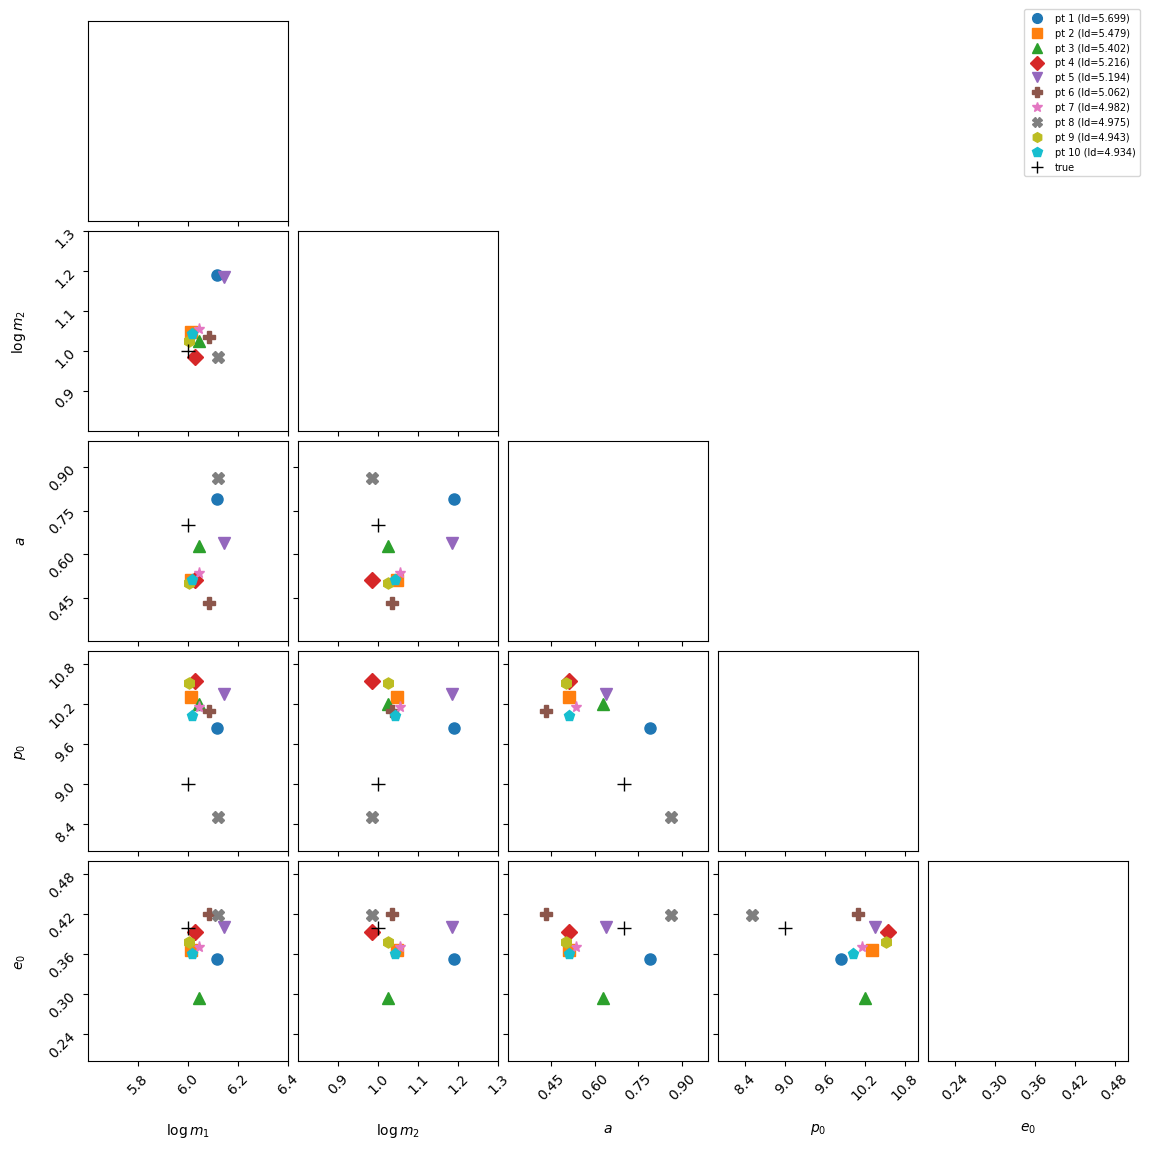

In [22]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

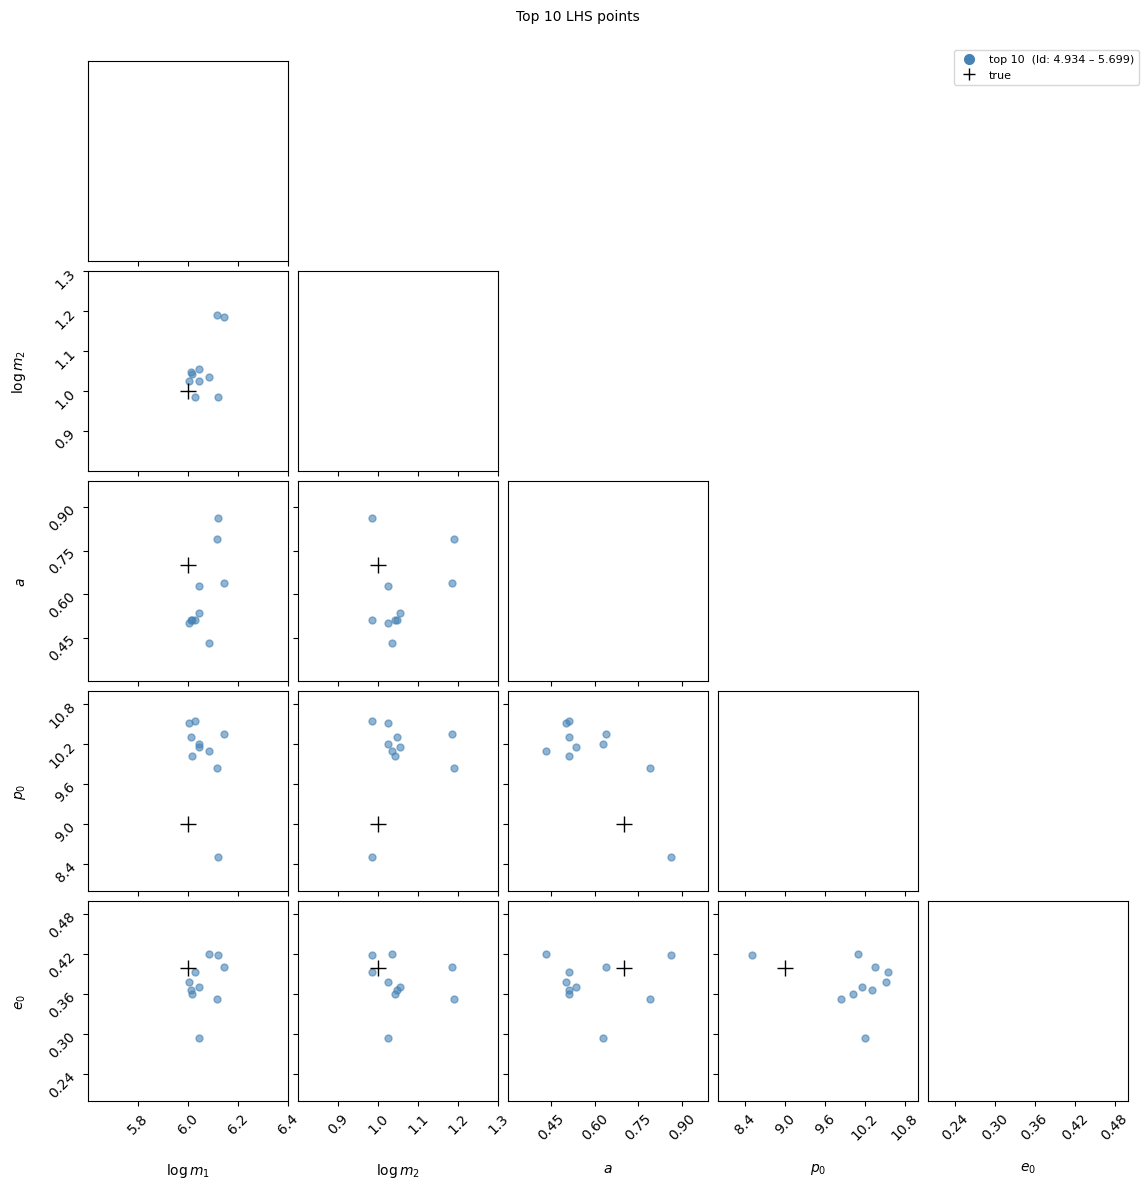

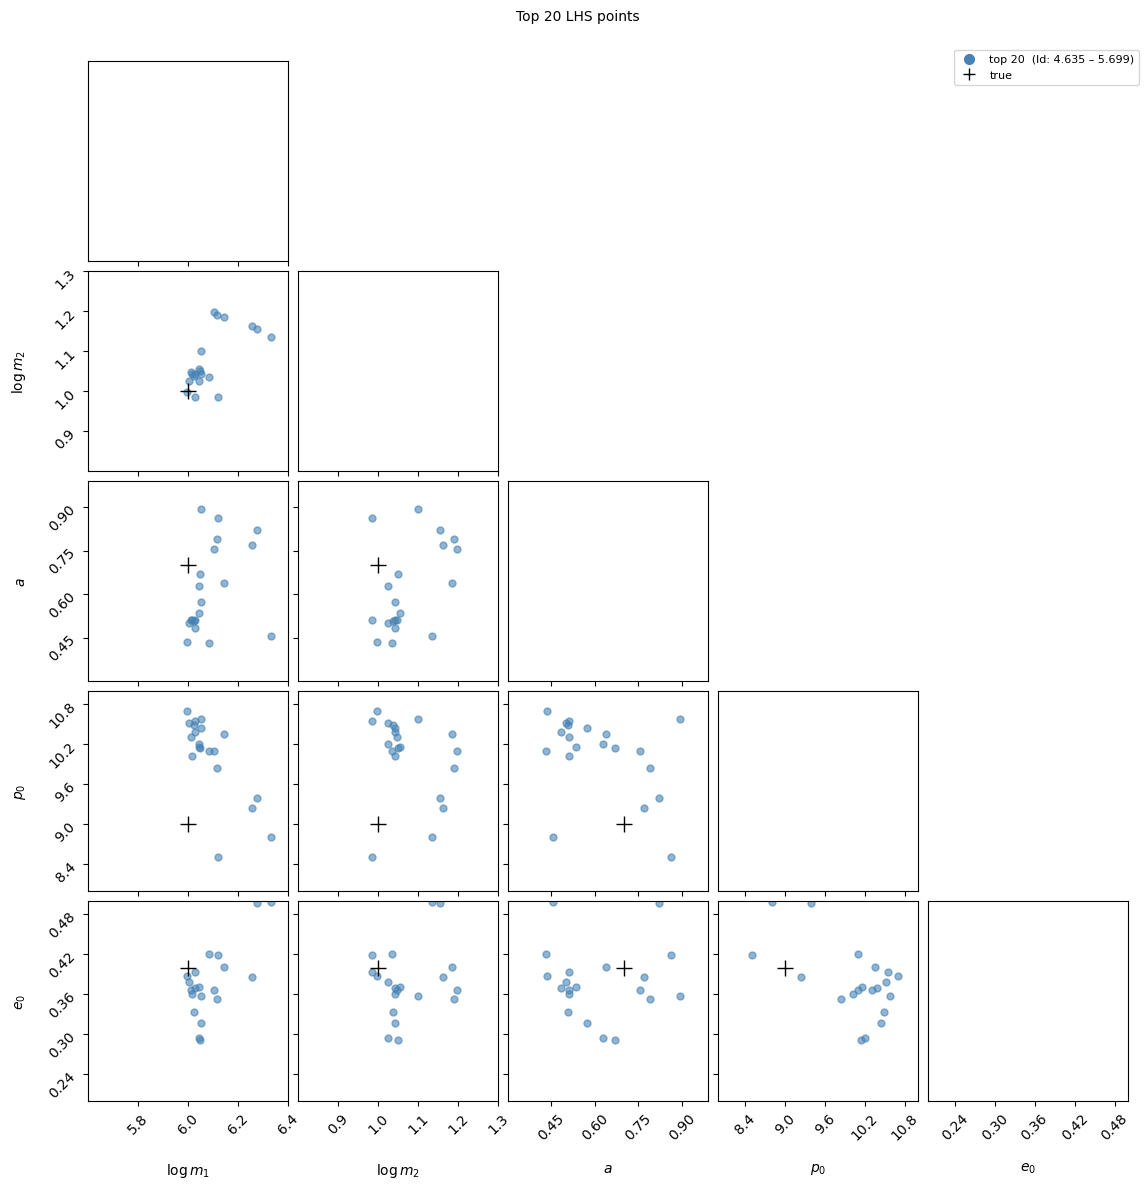

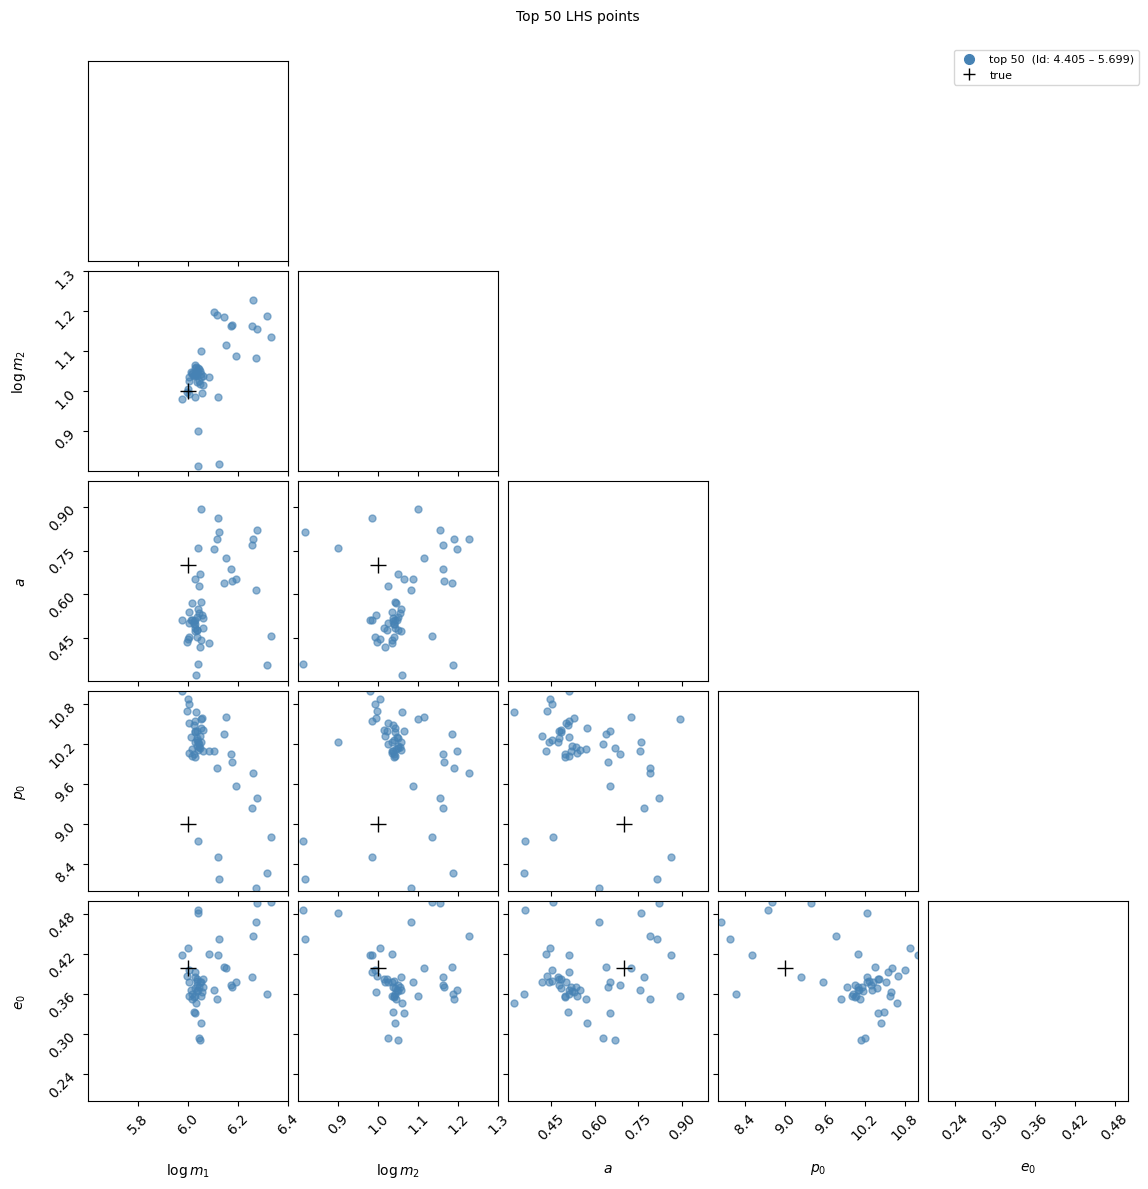

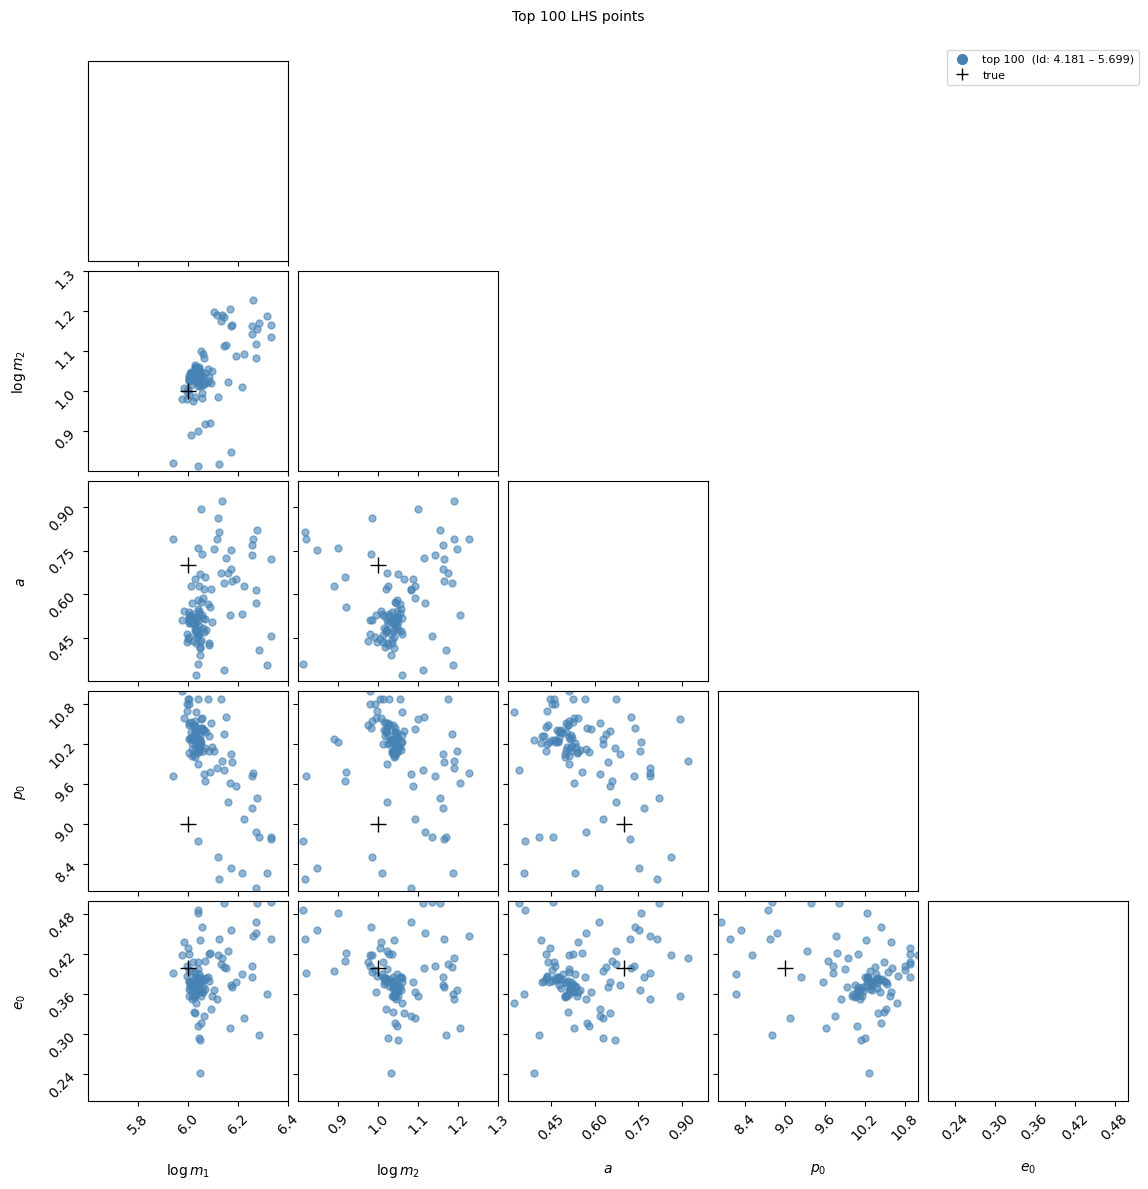

In [23]:
from matplotlib.lines import Line2D

all_logden = np.concatenate(logden_list)
sorted_idx = np.argsort(all_logden).flatten()

def plot_topN(N, color='steelblue', marker='o', ms=5):
    idx = sorted_idx[-N:][::-1]
    pts = prior_transform(proc_pt[0][idx])
    ld_vals = all_logden[idx]

    all_pts = np.vstack([pts, [true_params]])
    fig = corner.corner(all_pts, labels=labels, show_titles=False,
                        plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                        hist_kwargs=dict(alpha=0, lw=0))

    corner.overplot_points(fig, pts, color=color, marker=marker, ms=ms, alpha=0.6)
    corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=12, zorder=10)

    axes_arr = np.array(fig.axes).reshape((ndim, ndim))
    for row in range(ndim):
        for col in range(ndim):
            if col <= row:
                axes_arr[row, col].set_xlim(ranges[col])
            if col < row:
                axes_arr[row, col].set_ylim(ranges[row])

    handles = [
        Line2D([0],[0], color=color, marker=marker, ls='', ms=7,
                label=f'top {N}  (ld: {ld_vals[-1]:.3f} – {ld_vals[0]:.3f})'),
        Line2D([0],[0], color='black', marker='+', ls='', ms=9, label='true'),
    ]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
    fig.suptitle(f'Top {N} LHS points', fontsize=10, y=1.01)
    plt.show()

for N in [10, 20, 50, 100]:
    plot_topN(N)

# connection plot

In [24]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.1179571 , 1.18952974, 0.78922904, 9.84163333, 0.35247262]])

In [25]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [26]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [27]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [28]:
logden_theory_proc1

array([5.69902245, 3.34822426, 3.10594886, 4.03377982, 3.34691943,
       2.79254802, 3.3072011 , 4.03174466, 3.60357881, 3.79687101,
       3.29618618, 2.82878172, 2.54093996, 3.49093669, 2.35419187,
       3.33101755, 2.84483674, 3.11759931, 3.08707429, 2.2860067 ,
       2.48685824, 2.55084498, 3.17425611, 2.4874351 , 3.19334331,
       3.0849479 , 2.4339625 , 2.55232641, 3.26149457, 2.69570668,
       1.89906873, 2.32288949, 2.22478286, 2.99619444, 1.91938465,
       2.49390962, 2.48726839, 2.75788682, 2.79112446, 2.66158366,
       2.2013574 , 2.30940465, 2.20053842, 2.22715001, 2.49905612,
       1.82339935, 2.74584963, 3.36199057, 6.05299504, 9.92879914])

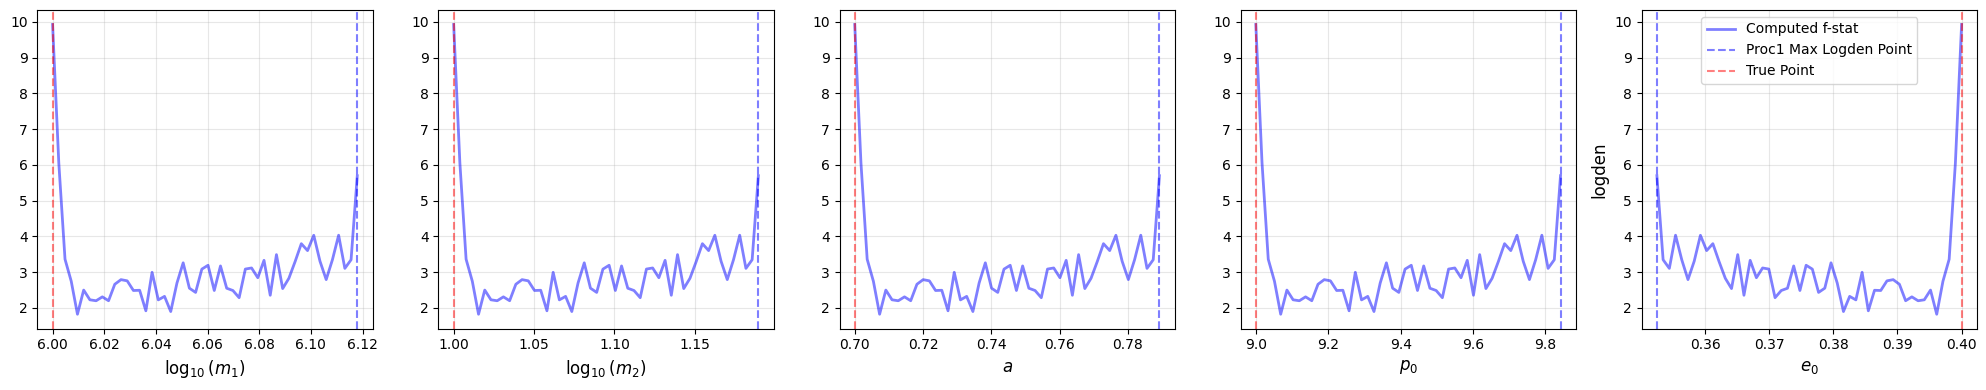

In [29]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


Initializing timemax...
Initializing phasemax...
Initializing tmXonly...
Initializing pure...
All initialized.
Evaluating timemax...
Evaluating phasemax...
Evaluating tmXonly...
Evaluating pure...
Done.


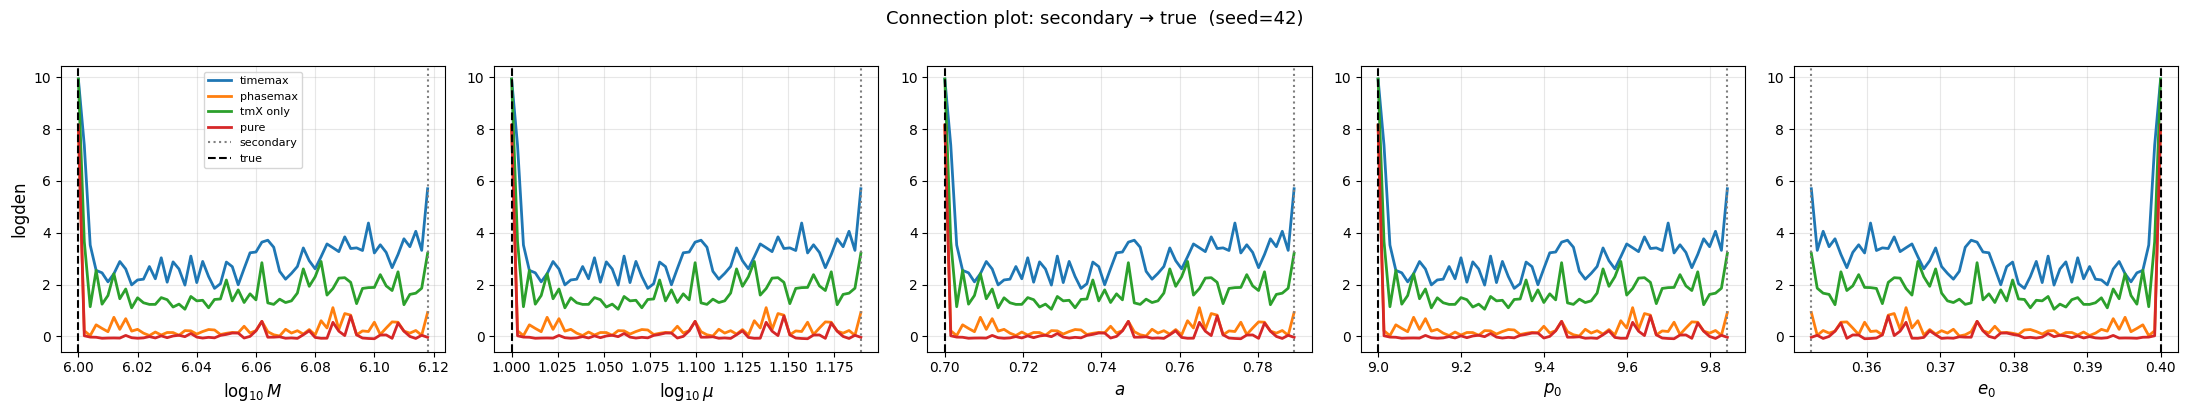

In [37]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

# ── re-use existing setup (params_star, waveform_response, gwf, xI0, dist, etc.)
# ── all 4 loglike variants share the same signal (same seed=42)

import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_tmXonly_noise
import loglike_pure_noise

ll_kwargs = dict(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)

print("Initializing timemax...")
ll_tm   = loglike_timemax_noise.LogLike(**ll_kwargs)
print("Initializing phasemax...")
ll_pm   = loglike_phasemax_noise.LogLike(**ll_kwargs)
print("Initializing tmXonly...")
ll_tmX  = loglike_tmXonly_noise.LogLike(**ll_kwargs)
print("Initializing pure...")
ll_pure = loglike_pure_noise.LogLike(**ll_kwargs)
print("All initialized.")

def make_log_density(ll_obj):
    """Wrap a LogLike object into a batched log_density function."""
    def _ld(params):
        params = np.asarray(params)
        out = np.zeros(params.shape[0])
        for i in range(params.shape[0]):
            logm1, logm2, a, p0, e0 = params[i]
            try:
                val = ll_obj(np.array([
                    10**logm1, 10**logm2, a, p0, e0,
                    xI0, dist, qS, phiS, qK, phiK,
                    Phi_phi0, Phi_theta0, Phi_r0
                ]))
            except Exception:
                val = -np.inf
            out[i] = val
        return out
    return _ld

ld_tm   = make_log_density(ll_tm)
ld_pm   = make_log_density(ll_pm)
ld_tmX  = make_log_density(ll_tmX)
ld_pure = make_log_density(ll_pure)

# ── connection line: secondary → true ─────────────────────────────────────────
secondary_pt =proc1_maxld_pt_1d.copy()

true_pt      = np.array([6.0, 1.0, 0.7, 9.0, 0.4])

n_points = 60
t_vals = np.linspace(0, 1, n_points)
# line_pts[dim, n_points]
line_pts = secondary_pt[:, None] + t_vals * (true_pt - secondary_pt)[:, None]

print("Evaluating timemax..."); ld_line_tm   = ld_tm(line_pts.T)
print("Evaluating phasemax..."); ld_line_pm   = ld_pm(line_pts.T)
print("Evaluating tmXonly..."); ld_line_tmX  = ld_tmX(line_pts.T)
print("Evaluating pure...");    ld_line_pure = ld_pure(line_pts.T)
print("Done.")

# ── plot ───────────────────────────────────────────────────────────────────────
variants = [
    ('timemax',   ld_line_tm,   'C0'),
    ('phasemax',  ld_line_pm,   'C1'),
    ('tmX only',  ld_line_tmX,  'C2'),
    ('pure',      ld_line_pure, 'C3'),
]

param_labels = [r'$\log_{10}M$', r'$\log_{10}\mu$', r'$a$', r'$p_0$', r'$e_0$']

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for dim in range(5):
    ax = axes[dim]
    for name, ld_line, color in variants:
        ax.plot(line_pts[dim], ld_line, '-', color=color, lw=2, label=name)
    ax.axvline(secondary_pt[dim], color='gray',  ls=':', lw=1.5, label='secondary')
    ax.axvline(true_pt[dim],      color='black', ls='--', lw=1.5, label='true')
    ax.set_xlabel(param_labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)
    if dim == 0:
        ax.set_ylabel('logden', fontsize=12)

axes[0].legend(fontsize=8, loc='best')
plt.suptitle('Connection plot: secondary → true  (seed=42)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [31]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [33]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [41]:
logden_tm = log_density(line_points_logm1.T)


In [43]:
logden_tm

array([      -inf,       -inf, 0.65612689, 1.23956561, 1.15023895,
       2.28280346, 1.37109758, 0.9816899 , 2.12282988, 1.79215818,
       1.42426588, 0.84266527, 1.96185085, 1.9403097 , 1.84903414,
       2.03460307, 1.83870762, 2.30768712, 1.09757154, 2.64110465,
       2.58745468, 2.31246063, 3.39096689, 1.42728748, 1.99819662,
       1.51325347, 2.90990433, 2.0947926 , 1.97364555, 3.29791473,
       1.606565  , 3.80860485, 2.93530506, 2.14553707, 2.39990774,
       3.78634229, 2.46956276, 3.24141337, 3.29587237, 3.12880581,
       3.85305429, 3.33015553, 2.894145  , 3.14465712, 4.3065303 ,
       2.40368789, 3.93302304, 3.53390063, 3.51964457, 3.46488602,
       2.20812314, 3.50706544, 3.2816705 , 2.8033345 , 3.32923592,
       3.64152626, 3.11835353, 2.63683549, 3.59985331, 3.72559233,
       2.54340409, 3.12000351, 2.9286627 , 4.25534126, 2.79260513,
       3.46974485, 3.28665651, 3.44511588, 3.0191249 , 2.83957348,
       5.41851571, 5.69902245, 3.87020826, 3.51049354, 3.54354

In [39]:
logden_pure = ld_pure(line_points_logm1.T)


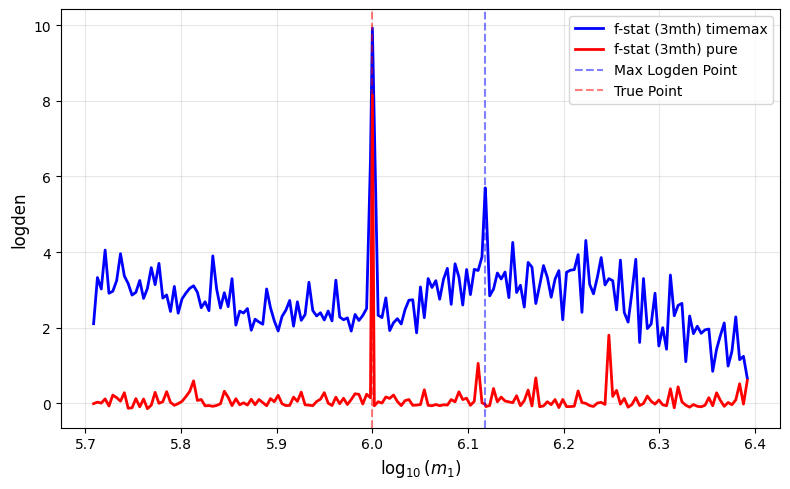

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

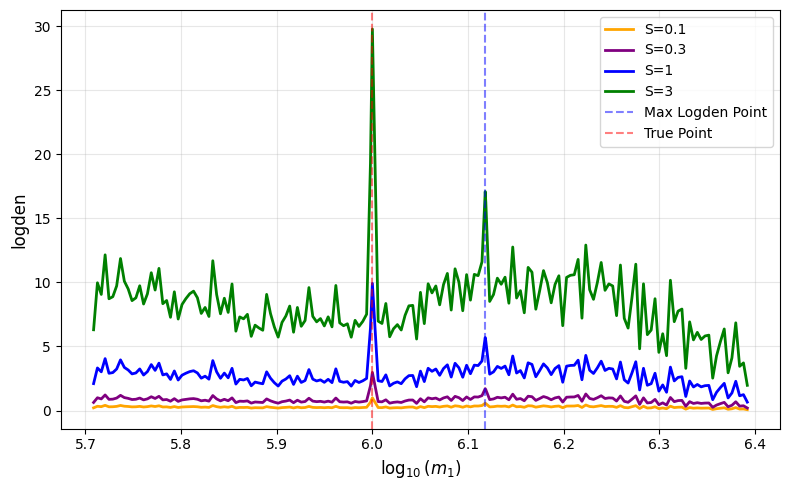

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm*0.1, '-', color='orange', linewidth=2, label='S=0.1')
ax.plot(line_points_logm1[0], logden_tm*0.3, '-', color='purple', linewidth=2, label='S=0.3')
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S=1')
ax.plot(line_points_logm1[0], logden_tm*3, '-', color='green', linewidth=2, label='S=3')
# ax.plot(line_points_logm1[0], logden_tm*10, '-', color='teal', linewidth=2, label='S=10')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()